### Tree 생성

In [24]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

# DeicisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156)

# 붗꽃 데이터를 로딩하고 학습과 테스트 데이터 셋으로 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

# 예측 -> 정확도
pred = dt_clf.predict(X_test)
print(f'예측 정확도: {np.round((accuracy_score(y_test, pred)),4)}')

예측 정확도: 0.9333


#### sklearn.tree.export_graphviz
* export_graphviz(decision_tree, out_file=None, *, max_depth=None, feature_names=None, class_names=None, label='all', filled=False, leaves_parallel=False, impurity=True, node_ids=False, proportion=False, rotate=False, rounded=False, special_characters=False, precision=3, fontname='helvetica')

* https://scikit-learn.org/stable/modules/generated/sklearn.tree.export_graphviz.html?highlight=graphviz#sklearn.tree.export_graphviz

In [25]:
from sklearn.tree import export_graphviz

# export_graphbiz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성
export_graphviz(dt_clf, out_file='tree.dot', class_names=iris_data.target_names,
                feature_names = iris_data.feature_names, impurity=True, filled=True)

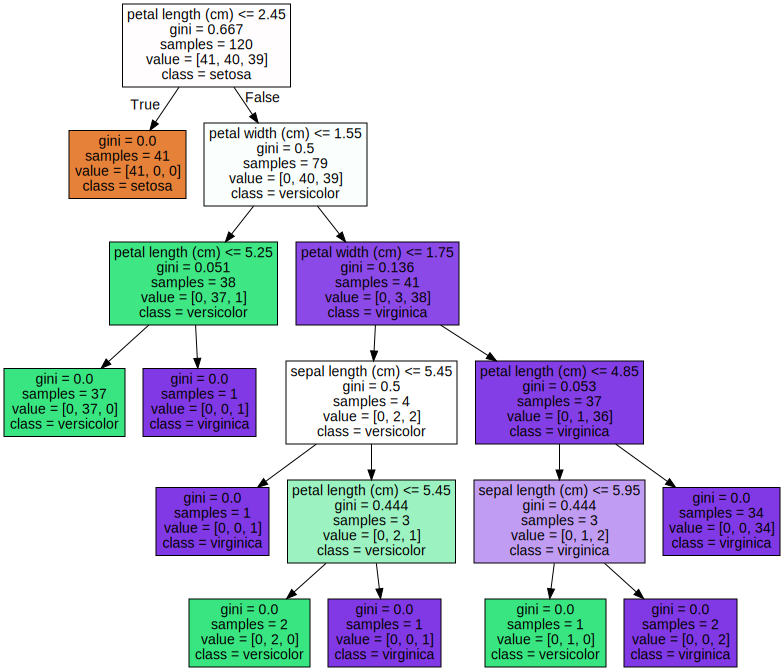

In [26]:
import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open('tree.dot') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

In [32]:
# feature 선택 중요도 확인해보기 (학습 시킨 후)
dt_clf.feature_importances_

array([0.02500521, 0.        , 0.55490281, 0.42009198])

In [35]:
# array [3:]이 높게 나왔기 때문에 해당하는 feature는 petal length, width
iris_data.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

#### max_depth = 3

In [41]:
# DeicisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156, max_depth=3)

# 붗꽃 데이터를 로딩하고 학습과 테스트 데이터 셋으로 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

# 예측 -> 정확도
pred = dt_clf.predict(X_test)
print(f'예측 정확도: {np.round((accuracy_score(y_test, pred)),4)}')

예측 정확도: 0.9333


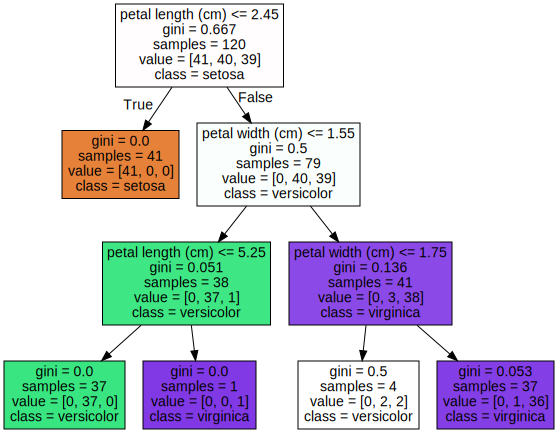

In [42]:
from sklearn.tree import export_graphviz

# export_graphbiz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성
export_graphviz(dt_clf, out_file='tree.dot', class_names=iris_data.target_names,
                feature_names = iris_data.feature_names, impurity=True, filled=True)

import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open('tree.dot') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

#### min_samples_split=4

In [ ]:
# DeicisionTree Classifier 생성
dt_clf = DecisionTreeClassifier(random_state=156, min_samples_split=4)

# 붗꽃 데이터를 로딩하고 학습과 테스트 데이터 셋으로 분리
iris_data = load_iris()
X_train, X_test, y_train, y_test = train_test_split(iris_data.data, iris_data.target,
                                                    test_size=0.2, random_state=11)

# DecisionTreeClassifier 학습
dt_clf.fit(X_train, y_train)

# 예측 -> 정확도
pred = dt_clf.predict(X_test)
print(f'예측 정확도: {np.round((accuracy_score(y_test, pred)),4)}')

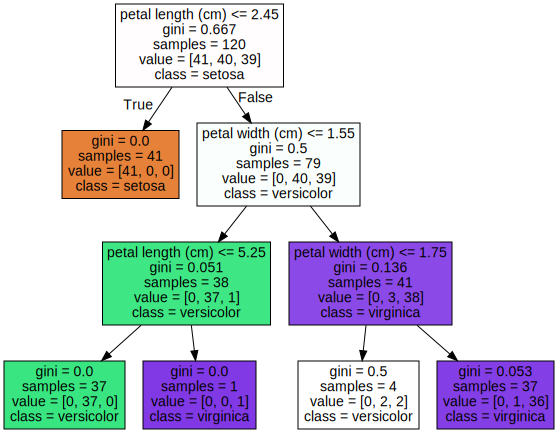

In [45]:
from sklearn.tree import export_graphviz

# export_graphbiz()의 호출 결과로 out_file로 지정된 tree.dot 파일을 생성
export_graphviz(dt_clf, out_file='tree.dot', class_names=iris_data.target_names,
                feature_names = iris_data.feature_names, impurity=True, filled=True)

import graphviz

# 위에서 생성된 tree.dot 파일을 Graphviz가 읽어서 시각화
with open('tree.dot') as f:
    dot_graph = f.read()
graphviz.Source(dot_graph)

### 결정 트리의 Feature 선택 중요도

Feature importance: 
[0.025 0.    0.555 0.42 ]
('sepal length (cm)', 0.02500520941862888)
('sepal width (cm)', 0.0)
('petal length (cm)', 0.5549028149313102)
('petal width (cm)', 0.42009197565006084)


<AxesSubplot:>

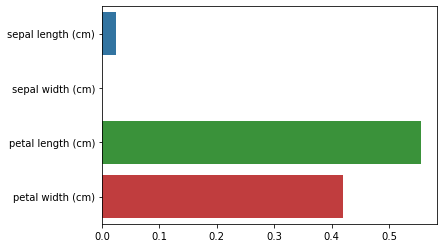

In [39]:
import seaborn as sns
import numpy as np
%matplotlib inline

# feature importance 추출
print(f"Feature importance: \n{np.round(dt_clf.feature_importances_, 3)}")

# feature별 importance 매핑
for name, value in zip(iris_data.feature_names, dt_clf.feature_importances_):
    print(f'{name, value}')

# feature importance를 columns 별로 시각화
sns.barplot(x=dt_clf.feature_importances_, y=iris_data.feature_names)

### DecisionTree 사용자 행동 인식 데이터 세트

In [57]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

# features.txt 파일에는 피처 이름 index와 피처명이 공백으로 분리되어 있음
# 이를 데이터프레임으로 로드
feature_name_df = pd.read_csv('./csv/features.txt', sep='\s+',
                              header=None, names=['column_index', 'column_name'])
# iloc[행 인덱스, 열 인덱스]
# data.iloc[0] # data의 첫번째 행만
# data.iloc[1] # 두번째 행만
# data.iloc[-1] # 마지막 행만
# Columns:
# data.iloc[:,0] # 첫번째 열만
# data.iloc[:,1] # 두번째 열만
# data.iloc[:,-1] # 마지막 열만

# 피처명 index를 제거하고, 피처명만 리스트 객체로 생성한 뒤 샘플로 10개만 추출
feature_name = feature_name_df.iloc[:, 1].values.tolist()
print(f'전체 피처명에서 10개만 추출: {feature_name[:10]}')

전체 피처명에서 10개만 추출: ['tBodyAcc-mean()-X', 'tBodyAcc-mean()-Y', 'tBodyAcc-mean()-Z', 'tBodyAcc-std()-X', 'tBodyAcc-std()-Y', 'tBodyAcc-std()-Z', 'tBodyAcc-mad()-X', 'tBodyAcc-mad()-Y', 'tBodyAcc-mad()-Z', 'tBodyAcc-max()-X']


In [ ]:
feature_name_df.head(20)

In [61]:
feature_dup_df = feature_name_df.groupby('column_name').count()
print(feature_dup_df[feature_dup_df['column_index'] > 1].count())
feature_dup_df[feature_dup_df['column_index'] > 1].head()

column_index    42
dtype: int64


,column_index
column_name,
"fBodyAcc-bandsEnergy()-1,16",3
"fBodyAcc-bandsEnergy()-1,24",3
"fBodyAcc-bandsEnergy()-1,8",3
"fBodyAcc-bandsEnergy()-17,24",3
"fBodyAcc-bandsEnergy()-17,32",3


In [86]:
import pandas as pd

df = pd.read_csv('./csv/human_activity.csv')
X_df = df.iloc[:, 0:10]

In [88]:
label = df.loc[:, 'Activity']

In [90]:
from sklearn.preprocessing import LabelEncoder
encoder = LabelEncoder()
y = encoder.fit_transform(label) 

In [66]:
len(y)

2947

In [97]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X_df, y, test_size=0.2, random_state=110)

In [102]:
X_df['label'] = y

In [69]:
X_df['label'].value_counts()

0    537
2    532
3    496
1    491
5    471
4    420
Name: label, dtype: int64

In [106]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

dt_clf = DecisionTreeClassifier(random_state=156)
dt_clf.fit(X_train, y_train)
pred = dt_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred)
print(f'결정 트리 예측 정확도: {accuracy}')

# DecisionTreeClassifier의 하이퍼 파라미터 추출
print(f'DecisionTreeClassifier 기본 하이퍼 파라미터: \n{dt_clf.get_params()}')

결정 트리 예측 정확도: 0.6644067796610169
DecisionTreeClassifier 기본 하이퍼 파라미터: 
{'ccp_alpha': 0.0, 'class_weight': None, 'criterion': 'gini', 'max_depth': None, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'random_state': 156, 'splitter': 'best'}


In [72]:
from sklearn.model_selection import GridSearchCV

params = {
    'max_depth' : [6, 8, 10, 12, 16, 20, 24]
}

grid_cv = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print(f'GridSearchCV 최고 평균 정확도 수치: {grid_cv.best_score_}')
print(f'GridSearchCV 최적 하이퍼 파라미터: {grid_cv.best_params_}')


Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.6987576019288207
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 10}


In [76]:
# GridSearchCV객체의 cv_result_ 속성을 DataFrame 생성
cv_results_df = pd.DataFrame(grid_cv.cv_results_)

# max_depth 파라미터 값과 그때의 테스트(Evaluation)셋, 학습 데이터 셋의 정확도 수치 추출
cv_results_df[['param_max_depth', 'mean_test_score']]

,param_max_depth,mean_test_score
0,6,0.671613
1,8,0.694519
2,10,0.698758
3,12,0.690279
4,16,0.687304
5,20,0.685186
6,24,0.685186


In [84]:
max_depths = [6,8,10,12,16,20,24]
# max_depth 값을 변화시키면서 그때마다 학습과 테스트 셋에서의 예측 성능 측정
for depth in max_depths:
    dt_clf = DecisionTreeClassifier(max_depth=depth, random_state=156)
    dt_clf.fit(X_train, y_train)
    pred = dt_clf.predict(X_test)
    accuracy = accuracy_score(y_test, pred)
    print(f'max_depth = {depth}, 정확도: {accuracy}')

max_depth = 6, 정확도: 0.6610169491525424
max_depth = 8, 정확도: 0.6694915254237288
max_depth = 10, 정확도: 0.6644067796610169
max_depth = 12, 정확도: 0.6661016949152543
max_depth = 16, 정확도: 0.6728813559322034
max_depth = 20, 정확도: 0.6593220338983051
max_depth = 24, 정확도: 0.6644067796610169


In [111]:
params = {
    'max_depths' : [8,12,16,20],
    'min_samples_split' : [16,24],
}

grid_cf = GridSearchCV(dt_clf, param_grid=params, scoring='accuracy', cv=5, verbose=1)
grid_cv.fit(X_train, y_train)
print(f"GridSearchCV 최고 평균 정확도 수치: {grid_cv.best_score_}")
print(f"GridSearchCV 최적 하이퍼 파라미터: {grid_cv.best_params_}")

Fitting 5 folds for each of 7 candidates, totalling 35 fits
GridSearchCV 최고 평균 정확도 수치: 0.6987576019288207
GridSearchCV 최적 하이퍼 파라미터: {'max_depth': 10}


In [112]:
best_df_clf = grid_cv.best_estimator_
pred1 = best_df_clf.predict(X_test)
accuracy = accuracy_score(y_test, pred1)
print(f"결정 트리 예측 정확도: {accuracy}")

결정 트리 예측 정확도: 0.6644067796610169


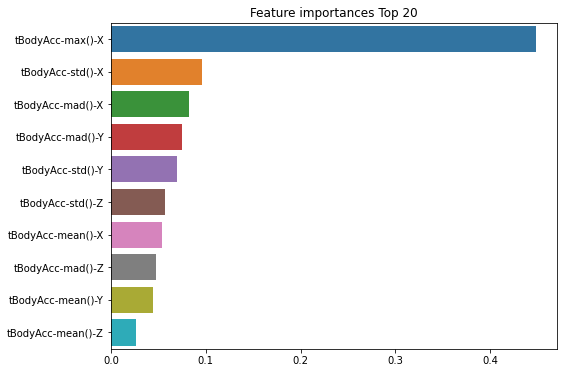

In [119]:
import seaborn as sns

ftr_importances_values = best_df_clf.feature_importances_
# Top 중요도로 정렬을 쉽게 하고, 시본(Seaborn)의 막대그래프로 쉽게 표현하기 위해 Series변환
ftr_importances = pd.Series(ftr_importances_values, index = X_train.columns)
# 중요도값 순으로 Series 정렬
ftr_top20 = ftr_importances.sort_values(ascending=False)[:20]
plt.figure(figsize=(8,6))
plt.title('Feature importances Top 20')
sns.barplot(x=ftr_top20, y = ftr_top20.index)
plt.show()


#### Voting Classifier

In [123]:
import pandas as pd
from sklearn.ensemble import VotingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

cancer = load_breast_cancer()

data_df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
data_df.head(3)


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst radius,worst texture,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension
0,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,19.69,21.25,130.0,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,23.57,25.53,152.5,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758


In [143]:
# 개별 모델은 로지스틱 회귀와 KNN
lr_clf = LogisticRegression()
knn_clf = KNeighborsClassifier(n_neighbors=8)

# 개별 모델을 소프트 보팅 기반의 앙상블 모델로 구현한 분류기
vo_clf = VotingClassifier(estimators=[('LR',lr_clf),('KNN',knn_clf)], voting='soft')

X_train, X_test, y_train, y_test = train_test_split(cancer.data, cancer.target, test_size=0.2, random_state=156)

# VotingClassifier 학습, 예측, 평가
vo_clf.fit(X_train, y_train)
pred = vo_clf.predict(X_test)
print(f'Voting 분류기 정확도: {np.round((accuracy_score(y_test,pred)),4)}')

# 개별 모델의 학습, 예측, 평가
classifiers = [lr_clf, knn_clf]
for classifier in classifiers:
    classifier.fit(X_train, y_train)
    pred = classifier.predict(X_test)
    class_name = classifier.__class__.__name__
    print(f"{class_name} 정확도: {(accuracy_score(y_test,pred).round(4))}")

Voting 분류기 정확도: 0.9474
LogisticRegression 정확도: 0.9386
KNeighborsClassifier 정확도: 0.9386


### sklearn.ensemble.RandomForestClassifier
* RandomForestClassifier(n_estimators=100, *, criterion='gini', max_depth=None, min_samples_split=2, min_samples_leaf=1, min_weight_fraction_leaf=0.0, max_features='sqrt', max_leaf_nodes=None, min_impurity_decrease=0.0, bootstrap=True, oob_score=False, n_jobs=None, random_state=None, verbose=0, warm_start=False, class_weight=None, ccp_alpha=0.0, max_samples=None)

* https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html?highlight=randomforest#sklearn.ensemble.RandomForestClassifier

In [1]:
print("Hello")

Hello
